In [2]:
print("Hello")

Hello


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)


In [4]:
X_train = np.load("../data/processed/X_train_eng.npy")
X_test = np.load("../data/processed/X_test_eng.npy")
y_train = np.load("../data/processed/y_train_eng.npy")
y_test = np.load("../data/processed/y_test_eng.npy")

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (RBF Kernel)": SVC(kernel="rbf", probability=True),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    )
}

In [6]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.794444,0.725000,0.527273,0.610526,0.865964
1,SVM (RBF Kernel),0.805556,0.833333,0.454545,0.588235,0.855855
0,Logistic Regression,0.794444,0.800000,0.436364,0.564706,0.848727


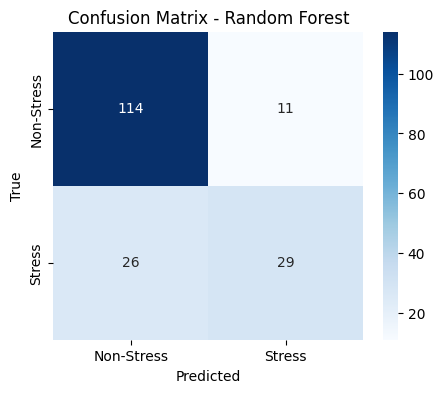

In [7]:
best_model = models["Random Forest"]
y_pred_rf = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Stress", "Stress"],
    yticklabels=["Non-Stress", "Stress"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Random Forest")
plt.show()


C:\Users\danis\AppData\Local\Temp\ipykernel_65424\2989283388.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


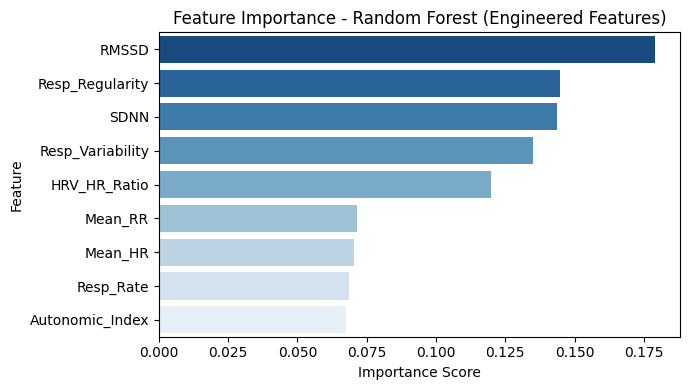

In [8]:
FEATURE_COLS = [
    "Mean_RR",
    "SDNN",
    "RMSSD",
    "Mean_HR",
    "Resp_Rate",
    "Resp_Variability",
    "HRV_HR_Ratio",
    "Resp_Regularity",
    "Autonomic_Index"
]

importance_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Importance": best_model.feature_importances_
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Plot
plt.figure(figsize=(7, 4))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    palette="Blues_r"
)

plt.title("Feature Importance - Random Forest (Engineered Features)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [9]:
import os

os.makedirs("../results/tables", exist_ok=True)

results_df.to_csv(
    "../results/tables/model_comparison_engineered.csv",
    index=False
)

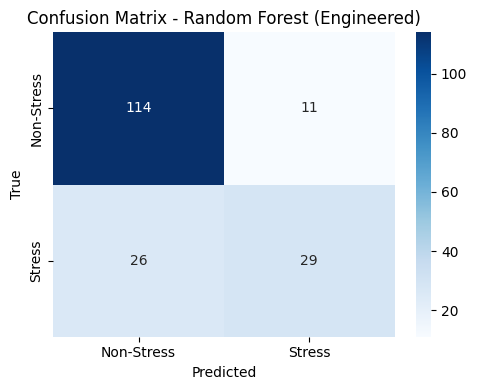

In [11]:
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Stress", "Stress"],
    yticklabels=["Non-Stress", "Stress"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Random Forest (Engineered)")
plt.tight_layout()

os.makedirs("../results/figures", exist_ok=True)
plt.savefig("../results/figures/confusion_matrix_rf_engineered.png", dpi=300)
plt.show()

C:\Users\danis\AppData\Local\Temp\ipykernel_65424\980069957.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


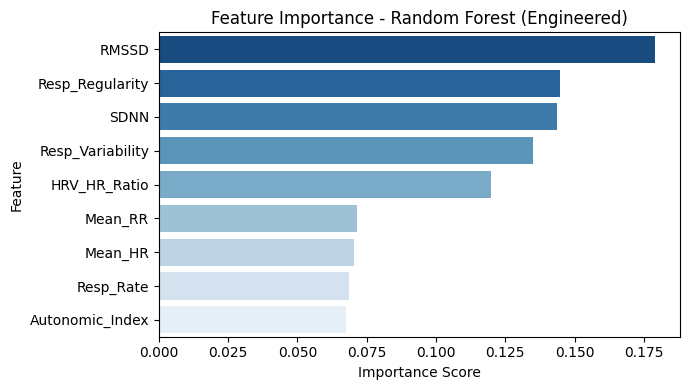

In [12]:
plt.figure(figsize=(7,4))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    palette="Blues_r"
)
plt.title("Feature Importance - Random Forest (Engineered)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    "../results/figures/feature_importance_rf_engineered.png",
    dpi=300
)
plt.show()


<Figure size 500x400 with 0 Axes>

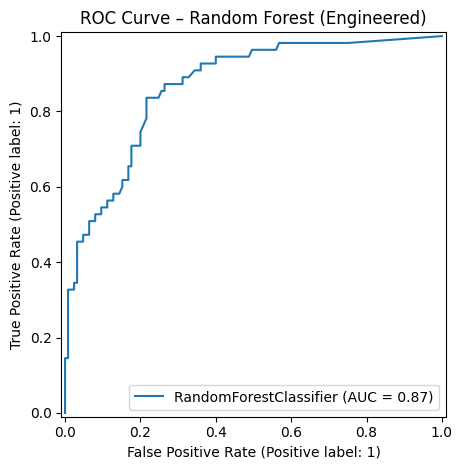

In [14]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(5,4))
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)
plt.title("ROC Curve – Random Forest (Engineered)")
plt.tight_layout()

plt.savefig(
    "../results/figures/roc_curve_rf_engineered.png",
    dpi=300
)
plt.show()